In [ ]:
import os
import glob
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import json

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.cuda.is_available())  # should print True
print(torch.cuda.get_device_name(0))  # should show T4 / P100 / V100

True
Tesla T4


In [3]:
class ISICDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.jpg")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*.png")))
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")  # grayscale mask

        img = img.resize((256, 256))
        mask = mask.resize((256, 256))

        img = TF.to_tensor(img)
        mask = torch.from_numpy(np.array(mask)).float() / 255.0
        mask = mask.unsqueeze(0)  # (1, H, W)

        if self.transform:
            img = self.transform(img)

        return img, mask

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.ReLU(),
            nn.Linear(dim*4, dim)
        )
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        # flatten (B, C, H, W) → (B, HW, C)
        B, C, H, W = x.shape
        x_flat = x.flatten(2).transpose(1, 2)

        attn_out, _ = self.attn(x_flat, x_flat, x_flat)
        x = self.norm1(x_flat + attn_out)
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        # reshape back
        x = x.transpose(1, 2).view(B, C, H, W)
        return x

class BAAModule(nn.Module):
    
    # Boundary-Aware Attention Module
    
    def __init__(self, in_ch):
        super().__init__()
        # Extract boundary (edge-like) features
        self.edge_conv = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1),
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True)
        )

        # Generate attention map
        self.attn = nn.Sequential(
            nn.Conv2d(in_ch, in_ch // 2, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch // 2, in_ch, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        edge_features = self.edge_conv(x)
        attn_map = self.attn(edge_features)
        return x * attn_map + edge_features  # enhances boundaries

class MBATransNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(in_ch, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        
        # Add Boundary-Aware Attention module
        self.baa = BAAModule(256)

        # Transformer bottleneck
        self.trans = TransformerBlock(256)

        # Decoder
        self.dec2 = ConvBlock(256+128, 128)
        self.dec1 = ConvBlock(128+64, 64)

        # Final
        self.final = nn.Conv2d(64, out_ch, 1)

        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)  # 64
        e2 = self.enc2(self.pool(e1))  # 128
        e3 = self.enc3(self.pool(e2))  # 256

        # Apply Boundary-Aware Attention
        b = self.baa(e3)
        # Transformer
        t = self.trans(e3)

        # Decoder
        d2 = torch.cat([nn.functional.interpolate(t, scale_factor=2, mode="bilinear"), e2], dim=1)
        d2 = self.dec2(d2)

        d1 = torch.cat([nn.functional.interpolate(d2, scale_factor=2, mode="bilinear"), e1], dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        return torch.sigmoid(out)

In [ ]:
#FLOPs
from thop import profile
import torch

# Create model
model = MBATransNet().cpu()

# Dummy input for FLOPs calculation
dummy_input = torch.randn(1, 3, 256, 256)

# Compute MACs + Params
macs, params = profile(model, inputs=(dummy_input,))

print(f"MACs : {macs/1e9:.3f} GMACs")
print(f"FLOPs: {(macs*2)/1e9:.3f} GFLOPs")   # MACs × 2 = FLOPs (standard rule)
print(f"Params: {params/1e6:.3f} Million")


[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
MACs : 34.062 GMACs
FLOPs: 68.124 GFLOPs
Params: 3.069 Million


In [7]:
def dice_loss(pred, target, smooth=1e-6):
    pred = pred.contiguous()
    target = target.contiguous()

    intersection = (pred * target).sum(dim=(2, 3))
    loss = 1 - ((2. * intersection + smooth) /
                (pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + smooth))
    return loss.mean()

#Other metrics

def iou_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) - intersection
    return ((intersection + smooth) / (union + smooth)).mean().item()

def accuracy_score(pred, target, smooth=1e-6):
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    return ((correct + smooth) / (total + smooth)).item()

def precision_score(pred, target, smooth=1e-6):
    tp = (pred * target).sum(dim=(2, 3))
    fp = (pred * (1 - target)).sum(dim=(2, 3))
    return ((tp + smooth) / (tp + fp + smooth)).mean().item()

def recall_score(pred, target, smooth=1e-6):
    tp = (pred * target).sum(dim=(2, 3))
    fn = ((1 - pred) * target).sum(dim=(2, 3))
    return ((tp + smooth) / (tp + fn + smooth)).mean().item()

def f1_score(pred, target, smooth=1e-6):
    prec = precision_score(pred, target, smooth)
    rec = recall_score(pred, target, smooth)
    return (2 * prec * rec) / (prec + rec + smooth)


In [10]:
import json

def save_checkpoint(model, optimizer, epoch, metrics, filename="checkpoint.pth", metrics_file="metrics.json"):
    # Save model + optimizer + epoch
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
    }, filename)

    # Save metrics history to JSON
    with open(metrics_file, "w") as f:
        json.dump(metrics, f)


def load_checkpoint(model, optimizer, filename="checkpoint.pth", metrics_file="metrics.json"):
    start_epoch = 0
    metrics = {"train_loss": [], "val_loss": [], "dice": [], "iou": [], "precision": [], "recall": [], "accuracy": []}

    if os.path.exists(filename):
        print(f"Loading checkpoint from {filename}...")
        checkpoint = torch.load(filename, map_location=device)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch'] + 1  # resume from next epoch

    if os.path.exists(metrics_file):
        with open(metrics_file, "r") as f:
            metrics = json.load(f)

    return model, optimizer, start_epoch, metrics

In [13]:

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4, checkpoint_file="checkpoint.pth", metrics_file="metrics.json"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [],
               "dice": [], "iou": [],"train_accuracy": [], "accuracy": [], "precision": [], "recall": [], "f1": []}

    # Load checkpoint if exists
    model, optimizer, start_epoch, metrics = load_checkpoint(model, optimizer, checkpoint_file, metrics_file)

    if start_epoch > 0:
      print(f"Resuming training from epoch {start_epoch}...")
    else:
      print("Starting training from scratch...")

    for epoch in range(start_epoch, epochs):
        model.train()
        train_loss = 0
        train_acc=[]
        
        for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            loss = dice_loss(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        dice_scores, iou_scores, acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], [], [], []
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                val_loss += dice_loss(preds, masks).item()

                # Threshold
                preds_bin = (preds > 0.5).float()

                # Metrics
                dice_scores.append(1 - dice_loss(preds_bin, masks).item())
                iou_scores.append(iou_score(preds_bin, masks))
                acc_scores.append(accuracy_score(preds_bin, masks))
                prec_scores.append(precision_score(preds_bin, masks))
                rec_scores.append(recall_score(preds_bin, masks))
                f1_scores.append(f1_score(preds_bin, masks))

        # ---- Logging ----
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["dice"].append(np.mean(dice_scores))
        history["iou"].append(np.mean(iou_scores))
        history["train_accuracy"].append(np.mean(train_acc))
        history["accuracy"].append(np.mean(acc_scores))
        history["precision"].append(np.mean(prec_scores))
        history["recall"].append(np.mean(rec_scores))
        history["f1"].append(np.mean(f1_scores))

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f" Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}"
              f" Dice={np.mean(dice_scores):.4f}, IoU={np.mean(iou_scores):.4f}, "
              f" Accuracy={np.mean(acc_scores):.4f}, Precision={np.mean(prec_scores):.4f},"
              f" Recall={np.mean(rec_scores):.4f}, F1-Score={np.mean(f1_scores):.4f}")

        # ---- SAVE METRICS TO CSV ----
        with open(csv_file, mode="a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch + 1,
                avg_train_loss,
                avg_val_loss,
                np.mean(dice_scores),
                np.mean(iou_scores),
                np.mean(acc_scores),
                np.mean(prec_scores),
                np.mean(rec_scores),
                np.mean(f1_scores)
            ])

        # Save checkpoint
        save_checkpoint(model, optimizer, epoch, metrics, checkpoint_file, metrics_file)

    return model, history

In [ ]:
train_imgs = "path/to/train/images"
train_masks = "path/to/train/masks"
val_imgs = "path/to/validation/images"
val_masks = "path/to/validation/masks"
test_imgs = "path/to/test/images"
test_masks = "path/to/test/masks"

train_dataset = ISICDataset(train_imgs, train_masks)
val_dataset = ISICDataset(val_imgs, val_masks)
test_dataset = ISICDataset(test_imgs, test_masks)



In [15]:
from ptflops import get_model_complexity_info

def calculate_model_flops(model, input_res=(3, 256, 256)):
    macs, params = get_model_complexity_info(
        model,
        input_res,
        as_strings=True,
        print_per_layer_stat=False,
        verbose=False
    )
    print(f"FLOPs (MACs): {macs}")
    print(f"Parameters  : {params}")

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

model = MBATransNet().to(device)

table = []

modules = [
    ("Encoder Block 1", model.enc1, "input → enc1"),
    ("Encoder Block 2", model.enc2, "enc1 → enc2"),
    ("Encoder Block 3", model.enc3, "enc2 → enc3"),

    # NOTE: Corrected new order
    ("Boundary-Aware Attention", model.baa, "enc3 → BAA"),
    ("Transformer Bottleneck", model.trans, "BAA → Transformer"),

    ("Decoder Block 2", model.dec2, "Transformer → upsample + enc2"),
    ("Decoder Block 1", model.dec1, "dec2 → upsample + enc1"),

    ("Output Layer", model.final, "dec1 → final"),
]

for name, module_ref, connection in modules:
    out_shape = get_output_shape(module_ref)
    params = count_params(module_ref)
    activ = get_activation_layers(module_ref)

    table.append([name, out_shape, params, connection, activ])

# ---- Print formatted table ----
print("\n PARAMETERS TABLE \n")
print(f"{'Layer (type)':<30} {'Output Shape':<25} {'Parameters':<15} {'Connection':<35} {'Activations'}")
print("-"*140)

for row in table:
    print(f"{row[0]:<30} {str(row[1]):<25} {row[2]:<15} {row[3]:<35} {row[4]}")

model, history = train_model(model, train_loader, val_loader, epochs=90, lr=1e-4)

# Testing & Metrics
model.eval()
calculate_model_flops(model)
dice_scores, iou_scores,acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], [], [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        preds = (preds > 0.5).float()
        
        dice_scores.append(1 - dice_loss(preds, masks).item())
        iou_scores.append(iou_score(preds, masks))
        acc_scores.append(accuracy_score(preds, masks))
        prec_scores.append(precision_score(preds, masks))
        rec_scores.append(recall_score(preds, masks))
        f1_scores.append(f1_score(preds, masks))

print("\nFinal Test Metrics:")
print(f"Dice Score   : {np.mean(dice_scores):.4f}")
print(f"IoU Score    : {np.mean(iou_scores):.4f}")
print(f"Accuracy     : {np.mean(acc_scores):.4f}")
print(f"Precision    : {np.mean(prec_scores):.4f}")
print(f"Recall       : {np.mean(rec_scores):.4f}")
print(f"F1 Score     : {np.mean(f1_scores):.4f}")



 PARAMETERS TABLE 

Layer (type)                   Output Shape              Parameters      Connection                          Activations
--------------------------------------------------------------------------------------------------------------------------------------------
Encoder Block 1                ['-']                     38976           input → enc1                        ReLU, ReLU
Encoder Block 2                ['-']                     221952          enc1 → enc2                         ReLU, ReLU
Encoder Block 3                ['-']                     886272          enc2 → enc3                         ReLU, ReLU
Boundary-Aware Attention       ['-']                     656512          enc3 → BAA                          ReLU, ReLU, Sigmoid
Transformer Bottleneck         ['-']                     789760          BAA → Transformer                   ReLU
Decoder Block 2                ['-']                     590592          Transformer → upsample + enc2       ReLU,

Epoch 1/90: 100%|██████████| 163/163 [04:02<00:00,  1.49s/it]



Epoch 1/90
 Train Loss=0.4716, Val Loss=0.4349 Dice=0.6565, IoU=0.5369,  Accuracy=0.7759, Precision=0.5581, Recall=0.9427, F1-Score=0.6818


Epoch 2/90: 100%|██████████| 163/163 [03:42<00:00,  1.36s/it]



Epoch 2/90
 Train Loss=0.4106, Val Loss=0.4585 Dice=0.6935, IoU=0.5806,  Accuracy=0.8342, Precision=0.6112, Recall=0.9171, F1-Score=0.7128


...


Epoch 88/90
 Train Loss=0.0731, Val Loss=0.1812 Dice=0.8190, IoU=0.7212,  Accuracy=0.9198, Precision=0.8107, Recall=0.8917, F1-Score=0.8482


Epoch 89/90: 100%|██████████| 163/163 [03:48<00:00,  1.40s/it]



Epoch 89/90
 Train Loss=0.0720, Val Loss=0.1718 Dice=0.8284, IoU=0.7314,  Accuracy=0.9243, Precision=0.7858, Recall=0.9186, F1-Score=0.8461


Epoch 90/90: 100%|██████████| 163/163 [03:49<00:00,  1.41s/it]



Epoch 90/90
 Train Loss=0.0690, Val Loss=0.1686 Dice=0.8315, IoU=0.7388,  Accuracy=0.9304, Precision=0.8231, Recall=0.8797, F1-Score=0.8494
FLOPs (MACs): 52.52 GMac
Parameters  : 3.33 M

Final Test Metrics:
Dice Score   : 0.8741
IoU Score    : 0.7953
Accuracy     : 0.9240
Precision    : 0.8670
Recall       : 0.9137
F1 Score     : 0.8866


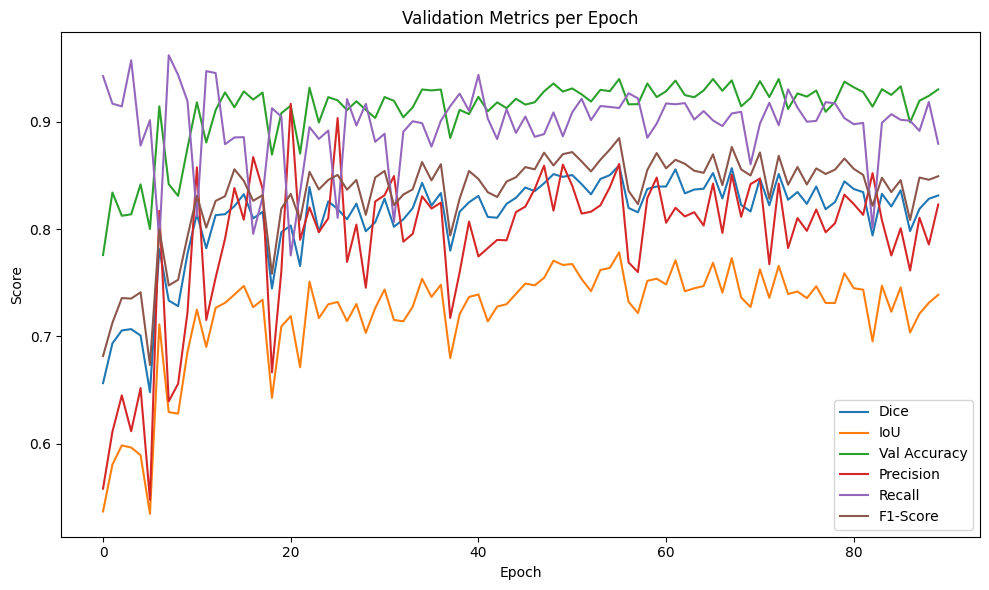

In [18]:
#Validation metrics

plt.figure(figsize=(10,6))
plt.plot(history["dice"], label="Dice")
plt.plot(history["iou"], label="IoU")
plt.plot(history["accuracy"], label="Val Accuracy")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.plot(history["f1"], label="F1-Score")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics per Epoch")
plt.legend()
plt.tight_layout()
plt.savefig("validation_metrics_old.png",dpi=900)
plt.show()


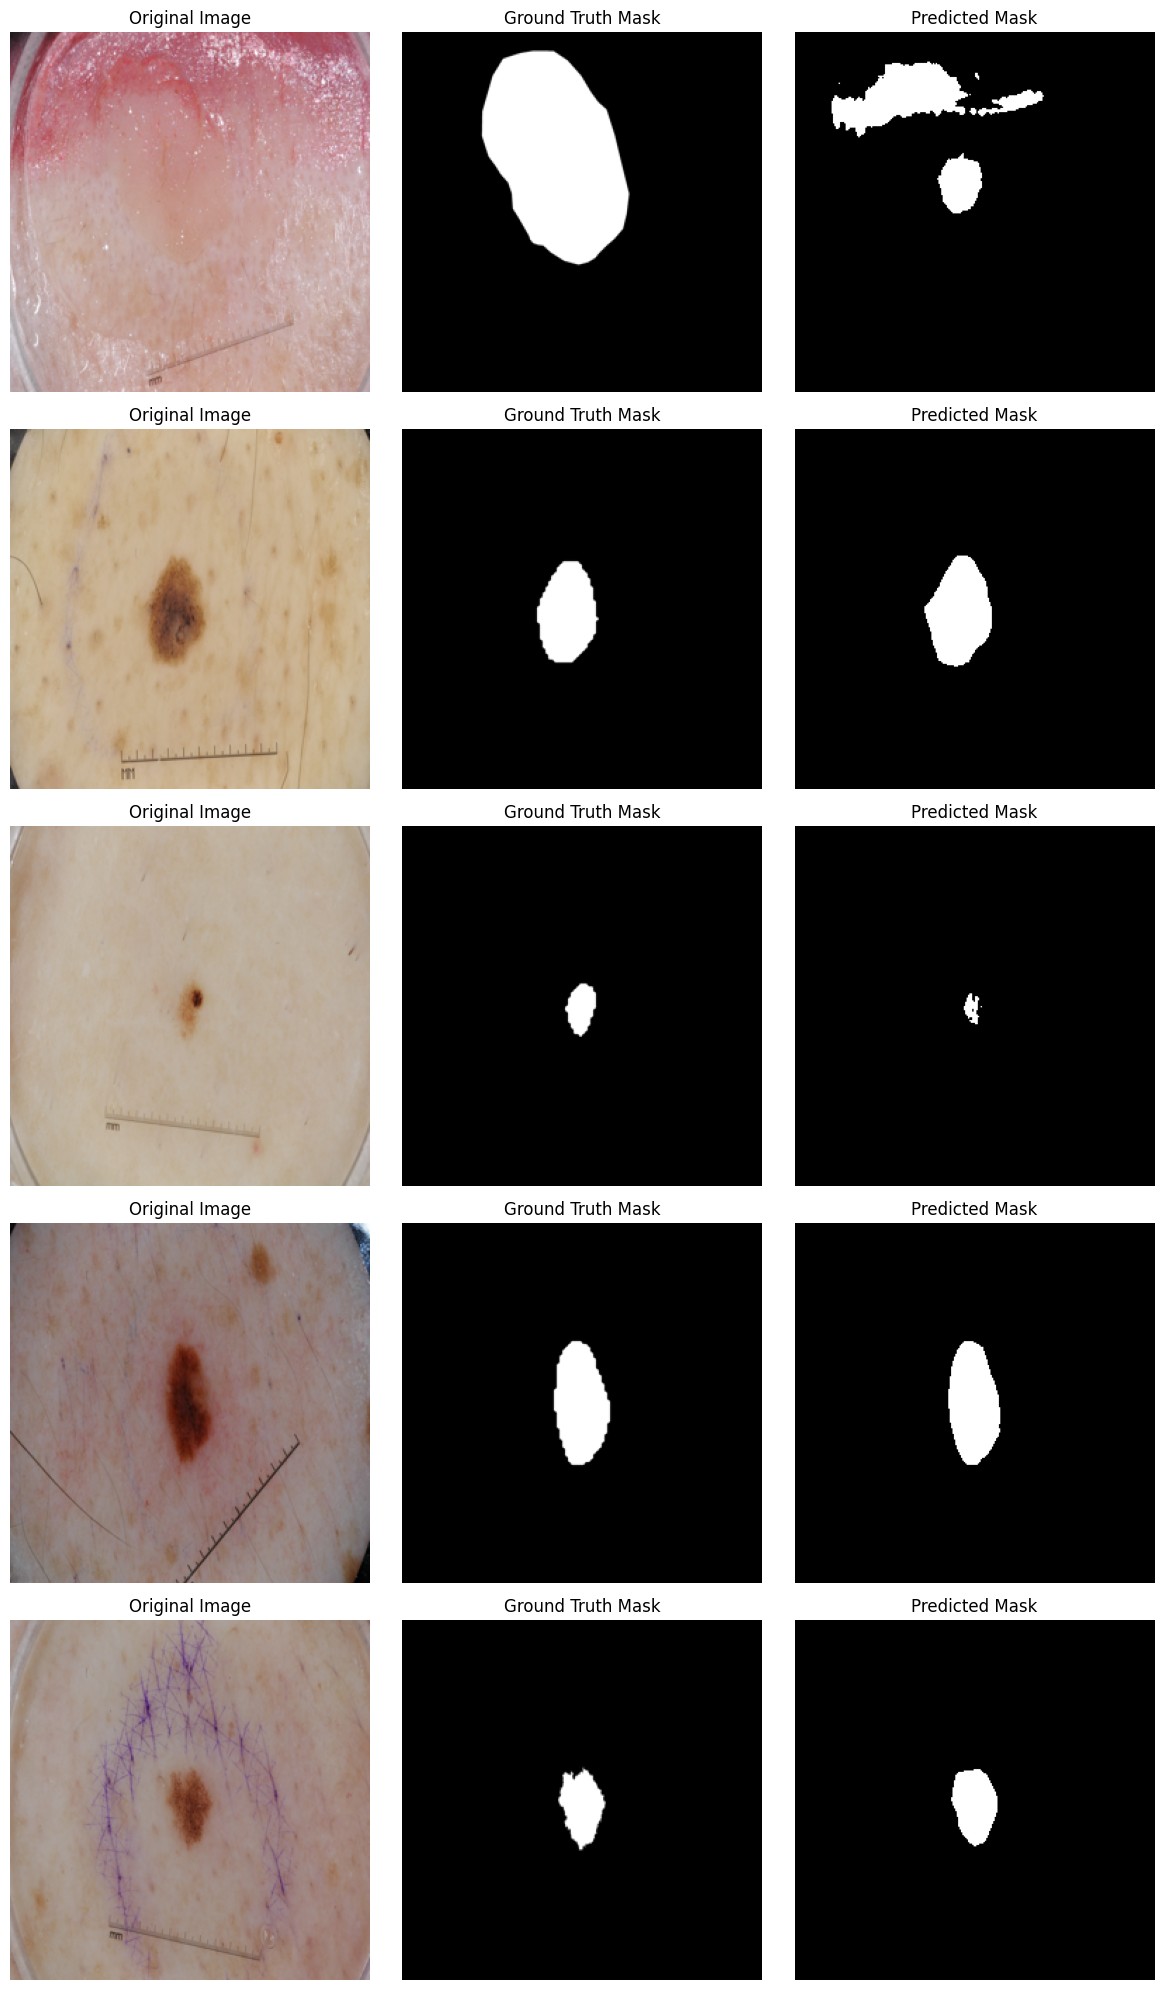

In [19]:
# Visualization of results
def visualize_predictions(model, dataset, num_samples=3):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples*4))

    for i in range(num_samples):
        img, mask = dataset[i]
        img_in = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(img_in)
            pred = (pred > 0.5).float().cpu().squeeze().numpy()

        # Convert tensors for plotting
        img_np = img.permute(1, 2, 0).numpy()
        mask_np = mask.squeeze().numpy()

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig("predicted_mask_old.png",dpi=900)
    plt.show()

# Call visualization
visualize_predictions(model, test_dataset, num_samples=5)